In [12]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage.color as skc
import skimage.io as skio

from itertools import combinations
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm


from utils.utils import (read_config, read_samples_df, 
                         class_to_rgb,
                         class_to_vegetal, class_to_artificial,
                         artificial_to_rgb, vegetal_to_rgb,
                         fast_down_sample, fast_up_sample,
                         read_image_collection
                         )
 

In [13]:
# small debug flag
verbose = False

In [14]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
conf = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir)

Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/test'),
 'files_csv': PosixPath('/workspaces/flairimages/data/test/testdataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/test/testdataset.pkl'),
 'image_collection': PosixPath('/workspaces/flairimages/data/test/testimagecollection.npy'),
 'image_collection_index': PosixPath('/workspaces/flairimages/data/test/testimagecollectionindex.npy'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs')}


In [15]:
# read the image and masks data in np.array format

# read the sample table in csv format
files_df = read_samples_df(conf=conf)
# set to  indexing by number for simplicity (and memory ?)
files_df.reset_index(drop=False, inplace=True)
if verbose:
    files_df.head()


In [16]:
image_data, image_indices = read_image_collection(conf=conf)


In [17]:

def show_image_and_masks(img:np.array,mask:np.array, alpha=0.5): 
    """
    Display the image and the masks in a 2x3 grid
    """   #
    plt.subplot(2,3,1)
    plt.imshow(img[:,:,:3])
    plt.title("R-G-B")
    plt.axis("off")
    #
    plt.subplot(2,3,2)
    plt.imshow(img[:,:,3:4])
    plt.title("NIR")
    plt.axis("off")
    #
    plt.subplot(2,3,3)
    plt.imshow(img[:,:,4])
    plt.title("Elévation")
    plt.axis("off")
    #
    msk_rgb = class_to_rgb(arr=mask, conf=conf)
    plt.subplot(2,3,4)
    plt.imshow(msk_rgb)
    plt.title("Mask")
    plt.axis("off")
    #
    msk_artificial = class_to_artificial(arr=mask, conf=conf)
    msk_rgb = artificial_to_rgb(arr=msk_artificial, conf=conf, alpha=alpha)
    plt.subplot(2,3,5)
    plt.imshow(img[:,:,:3])
    plt.imshow(msk_rgb)
    plt.title("Artificiel")
    plt.axis("off")
    #
    msk_vegetal = class_to_vegetal(arr=mask, conf=conf)
    msk_rgb = vegetal_to_rgb(arr=msk_vegetal, conf=conf, alpha=alpha)
    plt.subplot(2,3,6)
    plt.imshow(img[:,:,:3])
    plt.imshow(msk_rgb)
    plt.title("Végétal")
    plt.axis("off")
    #
    plt.tight_layout()


Full resolution original image


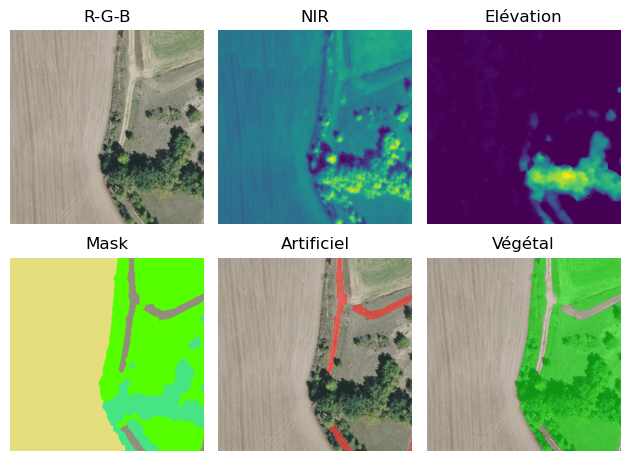

Downsampled image


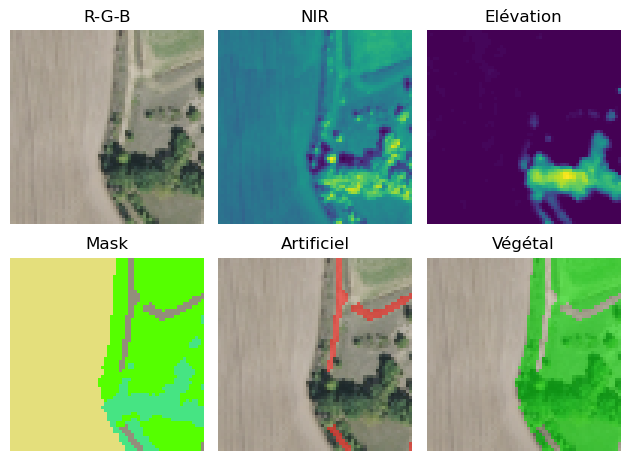

In [18]:
# see some images in original resolution and 
# set seed for df.sample() to get reproducible results
if False:
    seed = 10041958
    np.random.seed(seed)

#TODO: select a random index in image_indices, not directly from df
# select a random record from df
# and extract the name, image and mask file paths.
some_i = np.random.choice(image_indices.shape[0])
im_index = image_indices[some_i]

# down_sampled image and mask
img = image_data[some_i,:,:,:-3]
mask = image_data[some_i,:,:,-3]

# full resolution image and mask
name, image_file, mask_file = files_df.iloc[im_index][['name','image', 'mask']].values
img_full_resolution = skio.imread(image_file, plugin='tifffile')
mask_full_resolution = skio.imread(mask_file)
#
print(f"Full resolution original image")
show_image_and_masks(img=img_full_resolution, mask=mask_full_resolution)
plt.show()
print(f"Downsampled image")
show_image_and_masks(img=img, mask=mask)
plt.show()


if verbose:
#    
    print(f"conf['image_shape'] is {conf['image_shape']},")
    print(f"found {img_full_resolution.shape} in actual image, dtype:{img_full_resolution.dtype}")
    print(f"Actual mask of shape {mask_full_resolution.shape} , dtype:{mask_full_resolution.dtype}")
    print(f"found {img.shape} in downsampled image, dtype:{img_full_resolution.dtype}")
    print(f"downsampled mask of shape {mask.shape} , dtype:{mask.dtype}")

    print(f"min={tuple(img.min(axis=(0,1)))},\nmax={tuple(img.max(axis=(0,1)))}")


# Making inferences


### First we have the option to restrict the dataset to certain types of images
- e.g. type of camera, time of day (for shades), etc.

In [19]:
# remember
# files_df is the metadata table for all the images
# image_indices is a collection of indices into files_df
# image_data is an array of the corresponding images and masks

# subset files_df to only the images in image_data
#TODO: remove image_indices and use the index of the files_df directly
files_df = files_df.iloc[image_indices]
files_df.reset_index(drop=True, inplace=True)
assert(files_df.shape[0] == image_data.shape[0])


In [20]:
# check that the image data and metadata and mask are correctly matched
if verbose:
    print("images should be alike")
    plt.figure(figsize=(1,2))
    i = np.random.randint(0, image_data.shape[0])
    plt.subplot(1,2,1).imshow(image_data[i,:,:,:3])
    plt.axis('off')
    img_full_resolution = skio.imread(files_df.iloc[i]['image'], plugin='tifffile')
    plt.subplot(1,2,2).imshow(img_full_resolution[:,:,:3])
    plt.axis('off')
    plt.show()
    

In [21]:
# make a cross tabulation of the entries by camera and hour
# this will give us an idea of the distribution of the images
# by camera and hour
print(files_df.groupby('camera',observed=True)['camera'].count())
print('---------------------------------')
print(files_df.groupby('hour',observed=True)['hour'].count())
print('---------------------------------')
pd.crosstab(files_df['camera'], files_df['hour'])


camera
CAMERA#017         2050
CAMERA#020         2375
CAMERA#030         1725
CAMERA#034          100
UCE-M3-f100        2625
UCE-M3-f120-s06    3597
UCE-M3-f120-s07     200
UCE-M3-f120-s08    3028
Name: camera, dtype: int64
---------------------------------
hour
7      215
8     1705
9     3213
10    2713
11    1913
12    1211
13    1646
14    2609
15     378
16      97
Name: hour, dtype: int64
---------------------------------


hour,7,8,9,10,11,12,13,14,15,16
camera,,,,,,,,,,
CAMERA#017,0,128,825,375,272,150,100,200,0,0
CAMERA#020,0,0,457,668,450,200,300,200,100,0
CAMERA#030,0,475,150,17,0,383,398,202,3,97
CAMERA#034,90,10,0,0,0,0,0,0,0,0
UCE-M3-f100,125,244,257,510,434,81,344,530,100,0
UCE-M3-f120-s06,0,400,414,412,250,97,504,1445,75,0
UCE-M3-f120-s07,0,0,0,68,0,0,0,32,100,0
UCE-M3-f120-s08,0,448,1110,663,507,300,0,0,0,0


In [22]:

# see if the camera influences the type of image
files_df['artificial_rate'] = image_data[:,:,:,5].mean(axis=(1,2))
print(files_df.groupby('camera',observed=True)['artificial_rate'].mean())
files_df['vegetal_rate'] = image_data[:,:,:,6].mean(axis=(1,2))
print(files_df.groupby('camera',observed=True)['vegetal_rate'].mean())

# not much difference between the cameras

#TODO: get patch centroid in files_df to see in if the camera 



camera
CAMERA#017         6.259191
CAMERA#020         7.528491
CAMERA#030         6.576567
CAMERA#034         7.584590
UCE-M3-f100        6.573356
UCE-M3-f120-s06    5.979461
UCE-M3-f120-s07    6.231349
UCE-M3-f120-s08    6.231918
Name: artificial_rate, dtype: float64
camera
CAMERA#017         0.285689
CAMERA#020         0.252838
CAMERA#030         0.324043
CAMERA#034         0.001582
UCE-M3-f100        0.316558
UCE-M3-f120-s06    0.348841
UCE-M3-f120-s07    0.205715
UCE-M3-f120-s08    0.327989
Name: vegetal_rate, dtype: float64


### finally we only restric our dataset to the images around noon

In [23]:

#TODO: infer the hour of solar noon from the metadata
hour_flag = files_df['hour'] == 12

In [24]:
# Here we prepare dataframes of images and pixel for training and testing
# we will train the model pixel by pixel by subsampling the train images
n_pixel_train = 100000
n_pixels_test = 100000
# split the images in train and test
(train_image_data, 
 test_image_data,
 train_indices,
 test_indices) = train_test_split(image_data[hour_flag],
                                  image_indices[hour_flag],
                                  test_size=0.2,
                                  train_size=None,
                                  random_state=42)

# Here we make a dataframe of pixels in the train images
# that we will subsample to train the model pixel by pixel

# we don't need the image location in the dataframe to train the model pixel by pixel
pixel_df_columns = {#'index':files_df.index.dtype,
                    'R':np.uint8, 
                    'G':np.uint8, 
                    'B':np.uint8, 
                    'NIR':np.uint8, 
                    'Elevation':np.uint8,
                    'Class':np.uint8,
                    'Artificial':np.uint8,
                    'Vegetal':np.uint8}

# put all the pixels channels in columns
print(train_image_data.shape)
train_pixel_df = pd.DataFrame(data=train_image_data.reshape(-1, train_image_data.shape[-1]),
                              columns=pixel_df_columns.keys(), 
                              dtype=np.uint8).sample(n=n_pixel_train, random_state=42)
test_pixel_df = pd.DataFrame(data=test_image_data.reshape(-1, train_image_data.shape[-1]),
                              columns=pixel_df_columns.keys(), 
                              dtype=np.uint8).sample(n=n_pixels_test, random_state=43)
if verbose:
    print(train_pixel_df.info())
    print(test_pixel_df.info())


(968, 64, 64, 8)


In [25]:

# verify plausibility of the results
if verbose:
    train_pixel_df.groupby(by=['Class']).mean()


In [26]:
if verbose:
    train_pixel_df.groupby(by=['Vegetal']).mean()


In [27]:
if verbose:
    train_pixel_df.groupby(by=['Artificial']).mean()

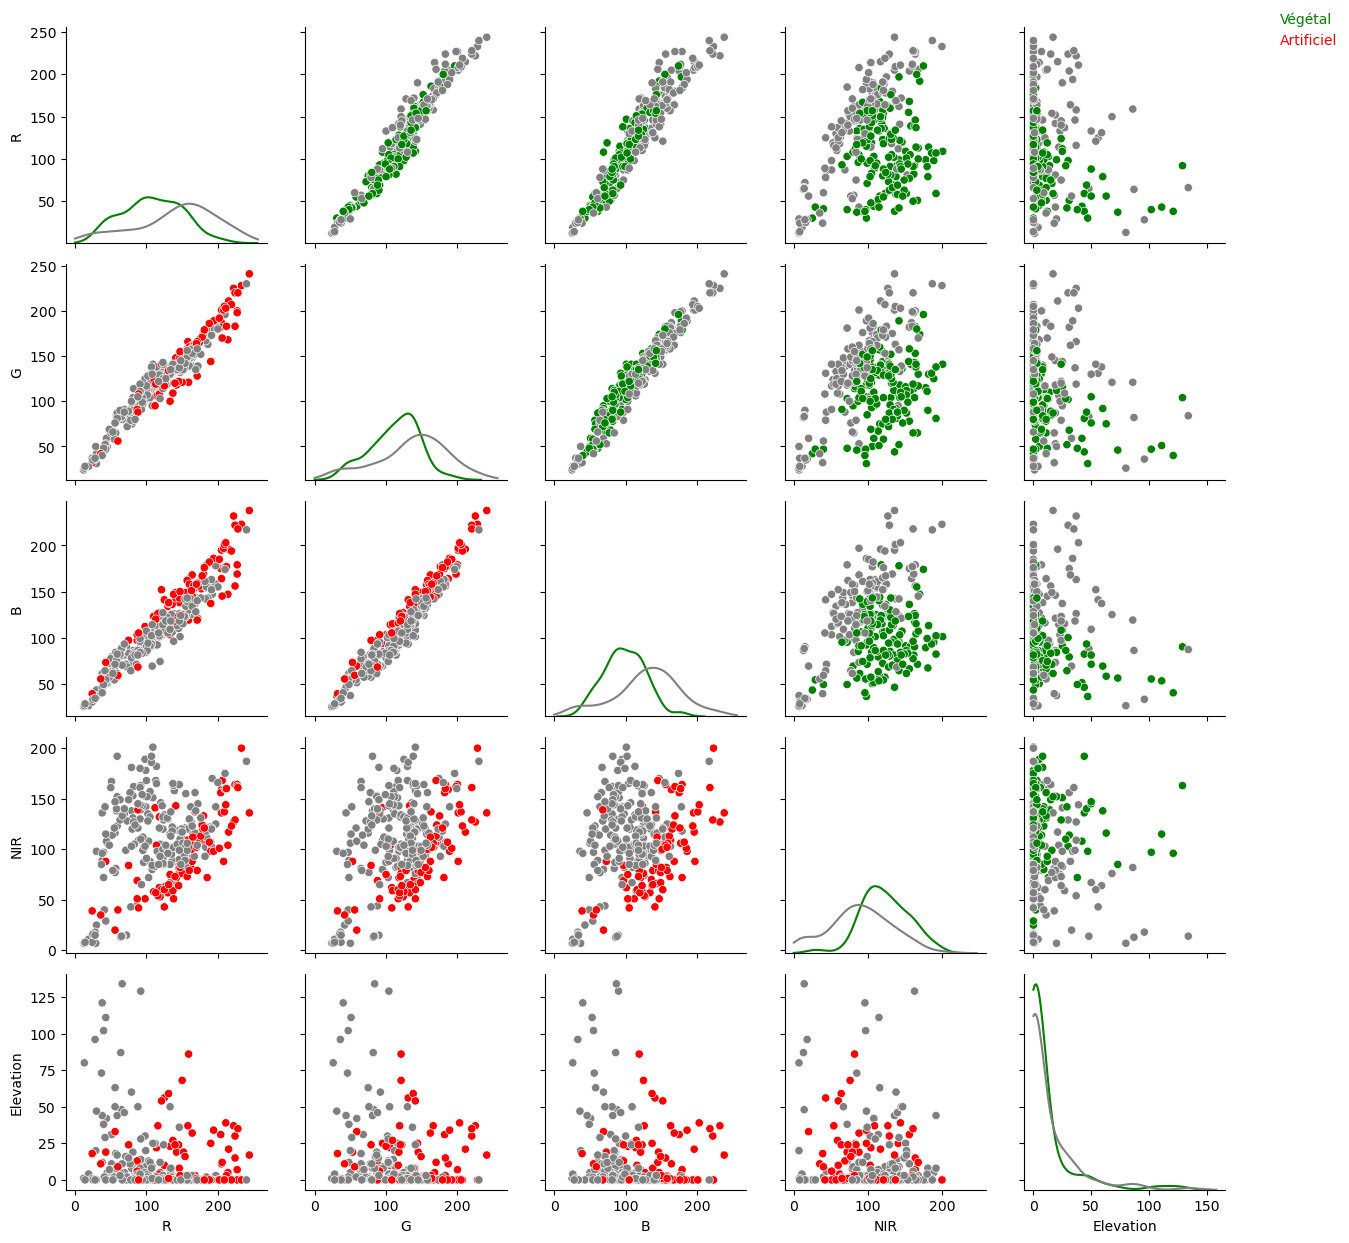

In [28]:
vars = ['R', 'G', 'B', 'NIR', 'Elevation']
vegetal_palette = sns.color_palette(["grey","green"])
artificial_palette = sns.color_palette(["grey","red"])
sub_df = train_pixel_df.sample(n=300, random_state=42)
g=sns.PairGrid(data=sub_df, vars=vars, hue='Vegetal', palette=vegetal_palette)

g.map_diag(sns.kdeplot, clip=[0,256])
#
g.map_upper(sns.scatterplot,hue = sub_df.Vegetal, palette=vegetal_palette)
#
g.map_lower(sns.scatterplot,hue = sub_df.Artificial, palette=artificial_palette) 
#
# add legend for upper plots hue
g.add_legend(label_order=['Végétal','Artificiel'], labelcolor=['green','red'], title='', loc='upper right')

plt.show()
 


In [29]:
# make many logist regression 
# to choose for a pedagogic progression
def make_logistic_regression(X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[('scaler', StandardScaler()),
                               ('log_reg', LogisticRegression(class_weight='balanced'))])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    # create a sklearn pipeline
    return pipeline, score


all_X_vars = ['R', 'G', 'B','NIR','Elevation']
all_y_vars = ['Artificial', 'Vegetal']

# enumerate all the possible combinations of 3 variables
estimators = dict()

for y_var in all_y_vars:
    estimators[y_var] = dict()
    for i in range (1, len(all_X_vars)+1):
        for X_vars in combinations(all_X_vars, i):
            #print(f"X_vars:{X_vars}")
            logreg, score = make_logistic_regression(X_train = train_pixel_df[list(X_vars)].values,
                                                     X_test  = test_pixel_df[list(X_vars)].values,
                                                     y_train = train_pixel_df[y_var].values,
                                                     y_test  = test_pixel_df[y_var].values)
            reg_equation = f"{y_var}~{'+'.join(X_vars)}"
            print(reg_equation+f"\t\t\t\t f score is {score}")
            estimators[reg_equation] = logreg
#TODO: output reusable markdown table

Artificial~R				 f score is 0.66043
Artificial~G				 f score is 0.67052
Artificial~B				 f score is 0.7611
Artificial~NIR				 f score is 0.65719
Artificial~Elevation				 f score is 0.65932
Artificial~R+G				 f score is 0.66653
Artificial~R+B				 f score is 0.85157
Artificial~R+NIR				 f score is 0.74364
Artificial~R+Elevation				 f score is 0.67966
Artificial~G+B				 f score is 0.88601
Artificial~G+NIR				 f score is 0.76791
Artificial~G+Elevation				 f score is 0.70419
Artificial~B+NIR				 f score is 0.81157
Artificial~B+Elevation				 f score is 0.7849
Artificial~NIR+Elevation				 f score is 0.67137
Artificial~R+G+B				 f score is 0.88316
Artificial~R+G+NIR				 f score is 0.76143
Artificial~R+G+Elevation				 f score is 0.69139
Artificial~R+B+NIR				 f score is 0.84487
Artificial~R+B+Elevation				 f score is 0.85527
Artificial~R+NIR+Elevation				 f score is 0.7571
Artificial~G+B+NIR				 f score is 0.88874
Artificial~G+B+Elevation				 f score is 0.88875
Artificial~G+NIR+Elevation				 f 

memo: in 'IMG_073414' prediction seems better than human mask

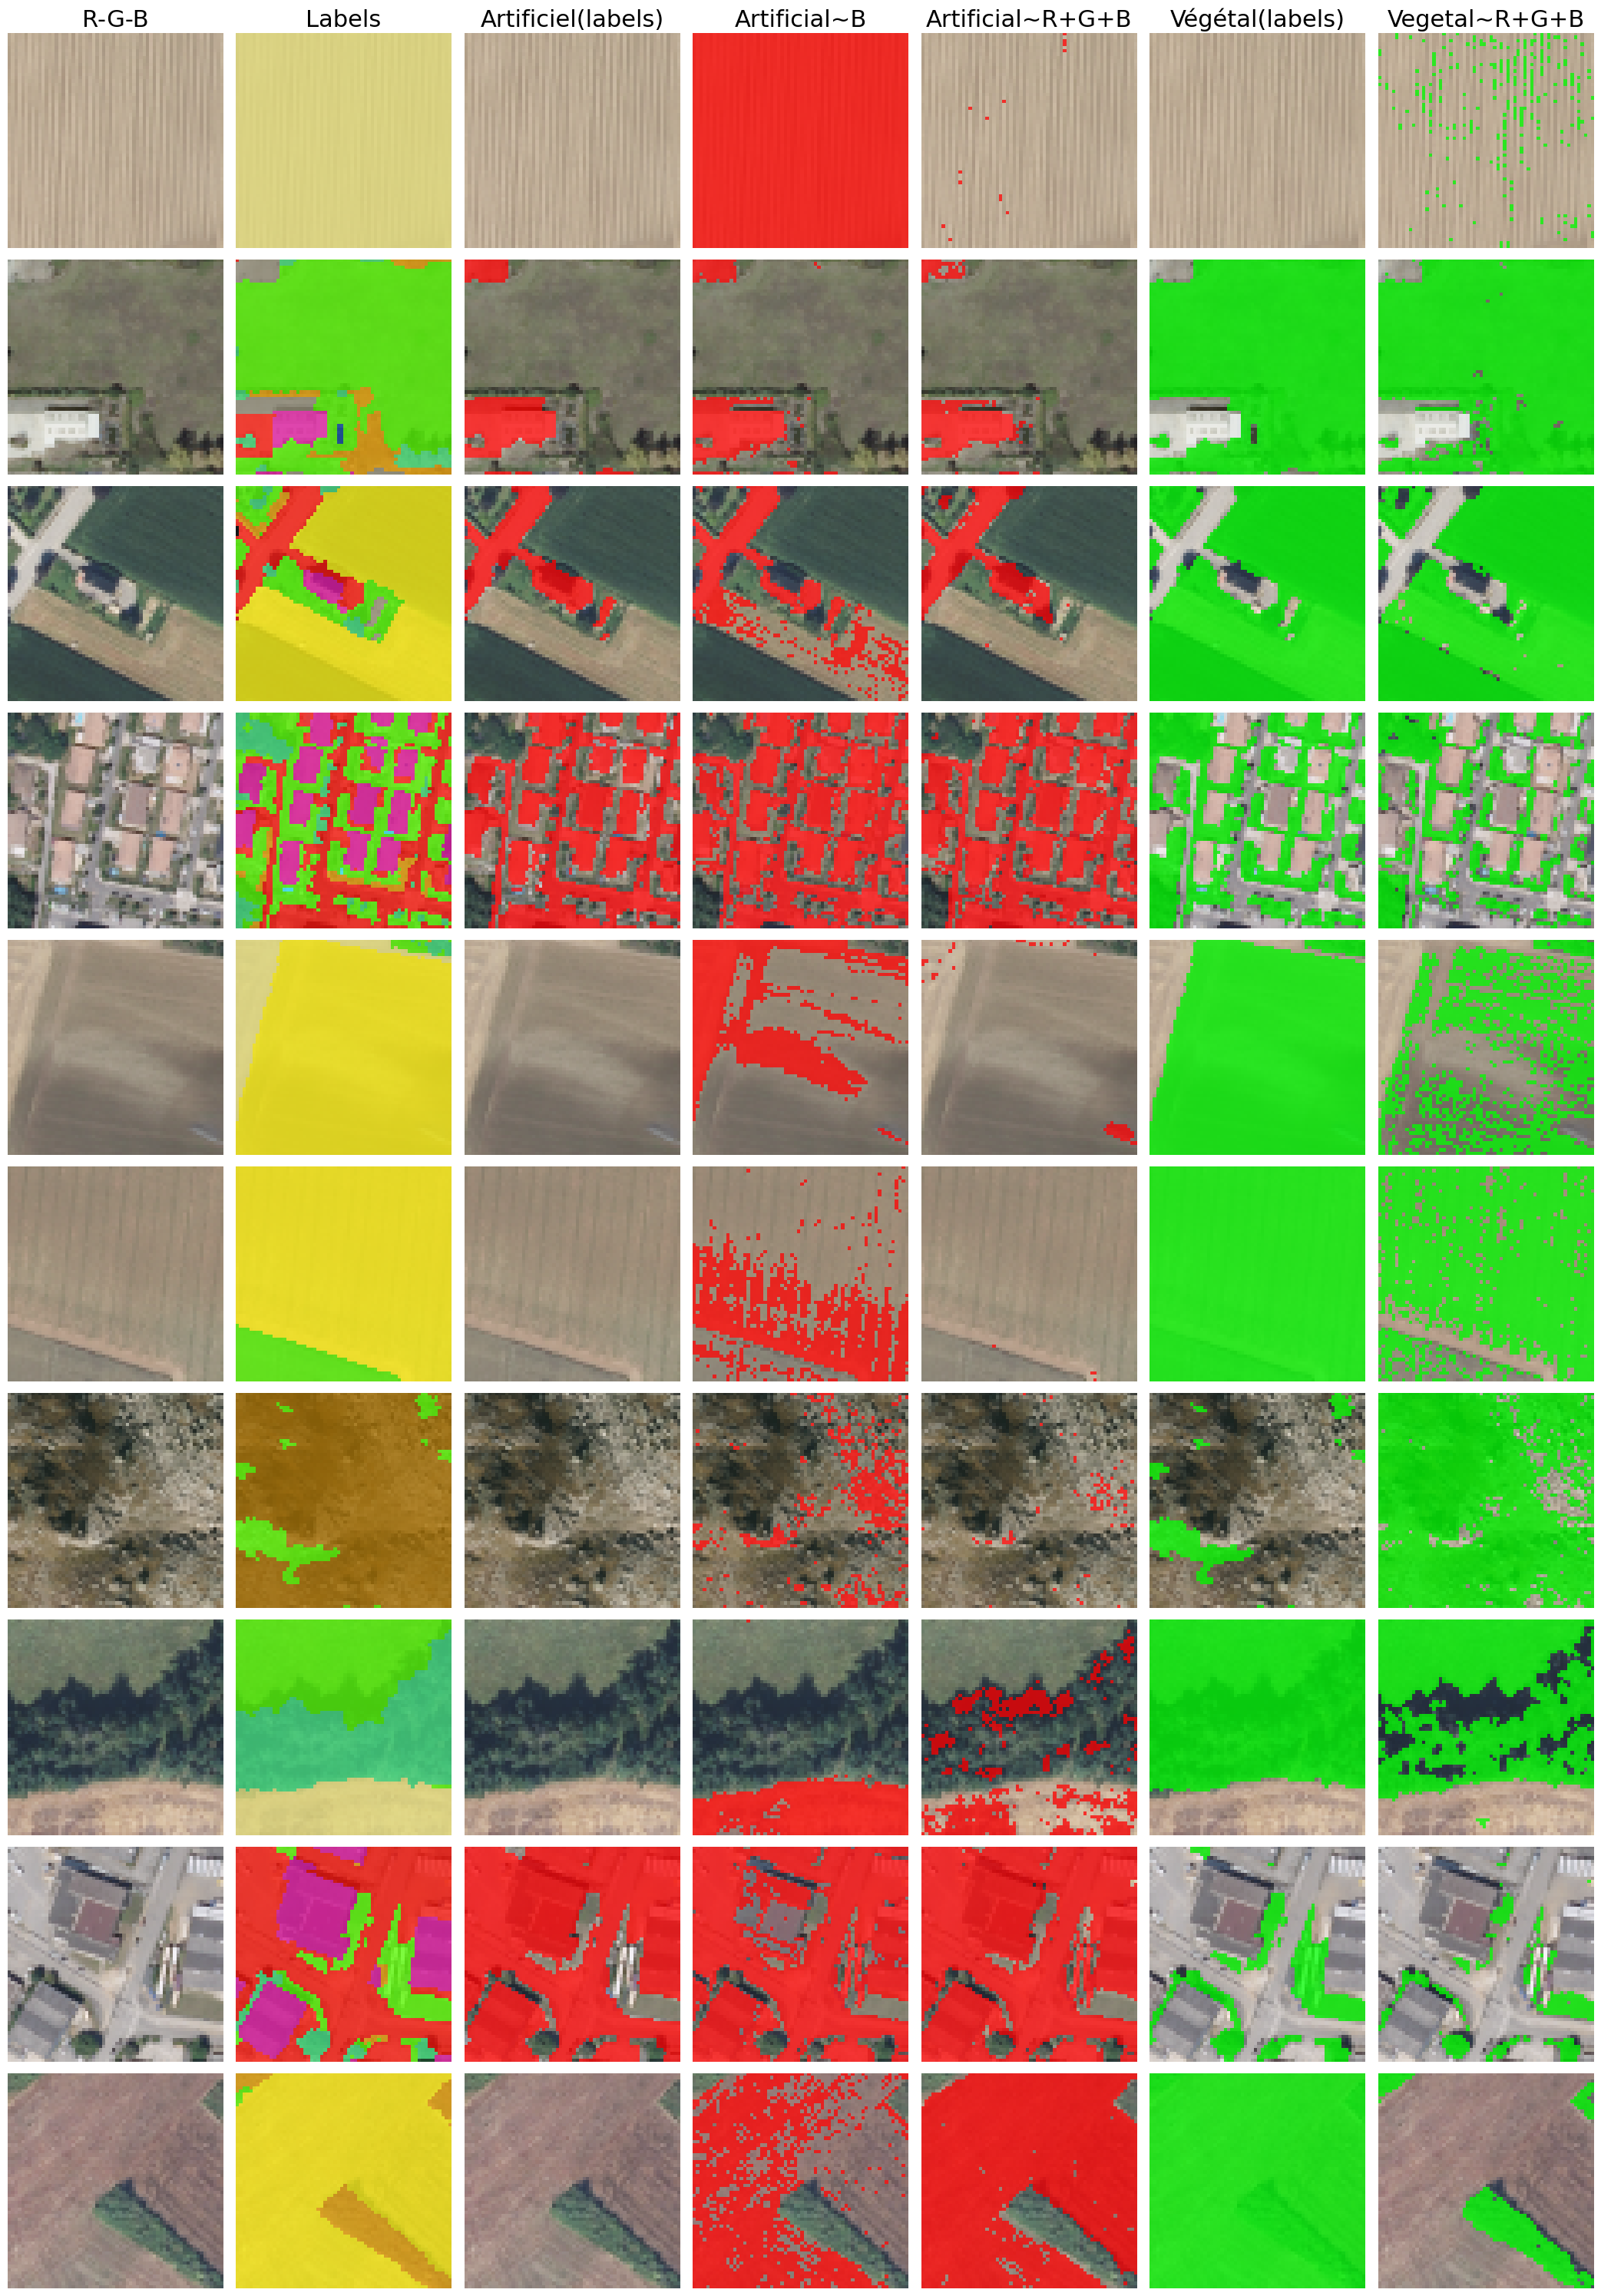

In [30]:
# set seed for df.sample() to get reproducible results
if False:
    seed = 10041958
    np.random.seed(seed)

# TODO: work from image_indices, not directly from df
# select a random record from df
# and extract the name, image and mask file paths.
# print(name)
# print(image_file)
# print(mask_file)
nl, nc = 10,7
im_alpha = 0.75
fontsize=22
plt.figure(figsize=(nc*3, nl*3))

for i_l, i_test_record in enumerate(np.random.choice(a=test_image_data.shape[0], size=nl)):
    record = test_image_data[i_test_record]
    im = record[:,:,:3]
    msk = record[:,:,-3]
    msk_a = record[:,:,-2]
    msk_v = record[:,:,-1]

    #    
    plt.subplot(nl, nc, i_l*nc+1)
    plt.imshow(im)
    if i_l == 0: plt.title("R-G-B", fontsize=fontsize)
    plt.axis("off")
    #
    msk_palette = class_to_rgb(arr=msk, conf=conf)
    plt.subplot(nl, nc, i_l*nc+2)
    plt.imshow(im)
    plt.imshow(msk_palette, alpha=im_alpha)
    
    if i_l == 0: plt.title("Labels", fontsize=fontsize)
    plt.axis("off")
    #
    rgb_label = artificial_to_rgb(arr=msk_a,  conf=conf, alpha=im_alpha)
    plt.subplot(nl, nc, i_l*nc+3)
    plt.imshow(im)
    plt.imshow(rgb_label)
    if i_l == 0: plt.title("Artificiel(labels)", fontsize=fontsize)
    plt.axis("off")
    #
    reg_equation = 'Artificial~B'
    msk_pred = estimators[reg_equation].predict(im[:,:,2].reshape(-1,1)).reshape(im.shape[:2])
    rgb_pred = artificial_to_rgb(conf=conf, arr=msk_pred, alpha=im_alpha)
    plt.subplot(nl, nc, i_l*nc+4)
    plt.imshow(im)
    plt.imshow(rgb_pred)
    if i_l == 0: plt.title(reg_equation, fontsize=fontsize)
    plt.axis("off")
    #
    reg_equation = 'Artificial~R+G+B'
    msk_pred = estimators[reg_equation].predict(im.reshape(-1,3)).reshape(im.shape[:2])
    rgb_pred = artificial_to_rgb(conf=conf, arr=msk_pred, alpha=im_alpha)
    plt.subplot(nl, nc, i_l*nc+5)
    plt.imshow(im)
    plt.imshow(rgb_pred)
    if i_l == 0: plt.title(reg_equation, fontsize=fontsize)
    plt.axis("off")
    #
    #
    rgb_vegetal = vegetal_to_rgb(arr=msk_v, conf=conf, alpha=im_alpha)
    plt.subplot(nl, nc, i_l*nc+6)
    plt.imshow(im)
    plt.imshow(rgb_vegetal)
    if i_l == 0: plt.title("Végétal(labels)", fontsize=fontsize)
    plt.axis("off")
    #

    reg_equation = 'Vegetal~R+G+B'
    msk_pred = estimators[reg_equation].predict(im.reshape(-1,3)).reshape(im.shape[:2])
    rgb_pred = vegetal_to_rgb(conf=conf, arr=msk_pred, alpha=im_alpha)
    plt.subplot(nl, nc, i_l*nc+7)
    plt.imshow(im)
    plt.imshow(rgb_pred)
    if i_l == 0: plt.title(reg_equation, fontsize=fontsize)
    plt.axis("off")
    #
plt.tight_layout()
plt.show()


(12, 17)
11 13 16 18
[27, 32, 18, 18]


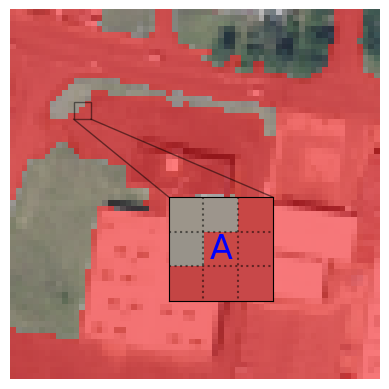

In [379]:

def plot_with_zoom(im, 
                   rgba_mask, 
                   pixel, 
                   extent=2, 
                   zoom_factor=4, 
                   ax=None, 
                   cross = None):
    if ax == None:
        fig, ax = plt.subplots()
    
    ax.imshow(im[:,:,:3], origin='upper') 
    ax.imshow(rgba_mask, origin='upper')
    print(pixel)
    # inset Axes....
    # subregion of the original image
    x1 = max(0, pixel[0]-extent)
    x2 = x1+2*extent
    if x2>im.shape[0]:
        x1 = im.shape[0]-2*extent-1
        x2 = im.shape[0]-1
    y1 = max(0,pixel[1]-extent)
    y2 = y1+2*extent
    if y2>im.shape[1]:
        y1 = im.shape[1]-2*extent-1
        y2 = im.shape[1]-1
    print(x1,x2,y1,y2)
    bounds = [(x1+im.shape[0]//4),
            (y1+im.shape[1]//4),
            zoom_factor*(2*extent+1),
            zoom_factor*(2*extent+1)]   
    if bounds[0]+bounds[2]>im.shape[0]:
        bounds[0] = im.shape[0]-bounds[2]
    if bounds[1]+bounds[3]>im.shape[1]:
        bounds[1] = im.shape[1]-bounds[3]    
          
    print(bounds)
    axins = ax.inset_axes(
        bounds = bounds,
        xlim=(x1-0.5,x2+0.5),
        ylim=(y2+0.5,y1-0.5),# note the invertion here
        xticklabels=[], yticklabels=[],
        transform=ax.transData)
    axins.imshow(im[:,:,:3], origin='upper')
    axins.imshow(rgba_mask, origin='upper')
    #axins.axis("off")
    axins.set_xticks([])
    axins.set_yticks([])
    
        #axins.axline(xy1=(x1, y1), xy2=(x2+1,y2+1), color='r', lw=2)
        #axins.axline(xy1=(x1, y2), xy2=(x2+1,y1-1), color='r', lw=2)
    text = "A"
    axins.text(x=pixel[0], y=pixel[1], 
                fontsize=24,s=text, color='b',
                ha='center', va='center')
    if cross:
        # hack to avoid drawing lines 
        for text in ["---", "--"]:
            axins.text(x=pixel[0], y=pixel[1],
                    fontsize=24,s =text, color='r',
                    ha='center', va='center')

    # hack to avoid messing with x_ticks
    side = 2*extent+1
    for x in range(x1,x2):
        axins.vlines(x=x+0.5, ymin=y1-0.5, ymax=y2+0.5, 
                     color="black", linestyles='dotted', alpha=0.5)    
    for y in range(y1,y2):
        axins.hlines(y=y+0.5, xmin=x1-0.5, xmax=x2+0.5, 
                     color="black", linestyles='dotted', alpha=0.5)    
        
            
        # axins.axline(xy1=(x1, y2-1), xy2=(x2+1,y1-1), color='r', lw=2)
        
    # this flips the y axis
    rectangle_patch, connector_lines=ax.indicate_inset_zoom(axins, edgecolor="black")
    connector_lines[0].set_visible(False)
    connector_lines[1].set_visible(True)
    connector_lines[2].set_visible(False)
    connector_lines[3].set_visible(True)
    
    #ax.axline(xy1=(x1,y1), xy2=(bounds[0],bounds[1]), color='black', lw=2)
    plt.axis("off")
    return ax
i_test_record = np.random.choice(test_image_data.shape[0])
record = test_image_data[i_test_record]
im = record[:,:,:3]
msk_a = record[:,:,-2]
rgba_mask = artificial_to_rgb(arr=msk_a, conf=conf, alpha=0.5)

plot_with_zoom(im=im, 
               rgba_mask=rgba_mask, 
               pixel=(12, 17), 
               extent=1, 
               zoom_factor=6, 
               cross=False)
plt.show()